In [41]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append("..")

from src.preprocessing import (
    load_data,
    check_data_quality,
    remove_duplicates,
    prepare_data
)

from src.train import (
    train_logistic_regression,
    train_random_forest
)

from src.evaluate import evaluate_model

In [42]:
import src.preprocessing as preprocessing

print(preprocessing.__file__)
print(dir(preprocessing))

/Users/neerajbhayal/Desktop/finalprojects/credit-card-fraud-detection/notebooks/../src/preprocessing.py
['SMOTE', 'StandardScaler', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'check_data_quality', 'load_data', 'pd', 'prepare_data', 'remove_duplicates', 'train_test_split']


In [43]:
df = load_data("../data/creditcard.csv")

print("Original Dataset Shape:", df.shape)

df.head()

Original Dataset Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [44]:
check_data_quality(df)


----- DATA QUALITY REPORT -----

Dataset Shape: (284807, 31)

Missing Values:
0

Duplicate Rows:
1081

Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Class Percentage:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


In [45]:
duplicate_count = df.duplicated().sum()

print(f"Duplicate Rows Found: {duplicate_count}")

# df_clean = df.drop_duplicates().copy()
df_clean = remove_duplicates(df)

print(f"Dataset Shape After Duplicate Removal: {df_clean.shape}")

print("\nClass Distribution After Duplicate Removal:")
print(df_clean["Class"].value_counts())

Duplicate Rows Found: 1081

----- DUPLICATE REMOVAL -----

Duplicate Rows Found: 1081
Dataset Shape After Duplicate Removal: (283726, 31)

Class Distribution After Duplicate Removal:
Class
0    283253
1       473
Name: count, dtype: int64
Dataset Shape After Duplicate Removal: (283726, 31)

Class Distribution After Duplicate Removal:
Class
0    283253
1       473
Name: count, dtype: int64


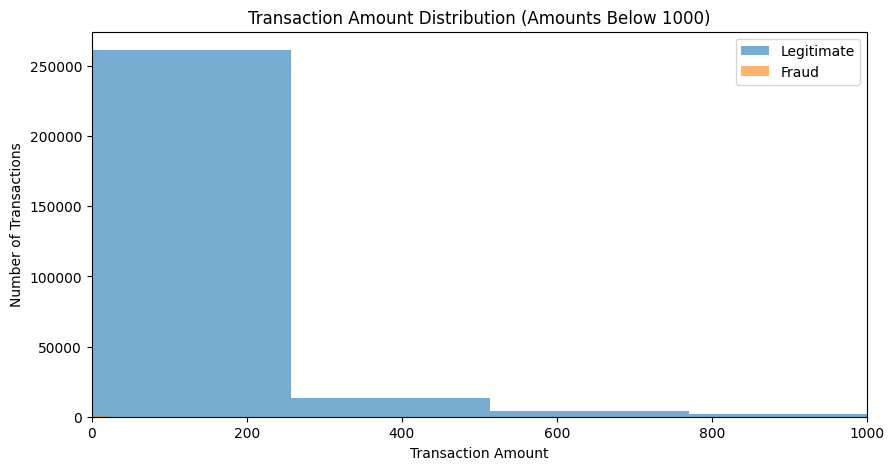

In [46]:
fraud_amounts = df_clean[df_clean["Class"] == 1]["Amount"]
legitimate_amounts = df_clean[df_clean["Class"] == 0]["Amount"]

plt.figure(figsize=(10, 5))

plt.hist(
    legitimate_amounts,
    bins=100,
    alpha=0.6,
    label="Legitimate"
)

plt.hist(
    fraud_amounts,
    bins=100,
    alpha=0.6,
    label="Fraud"
)

plt.xlim(0, 1000)

plt.title("Transaction Amount Distribution (Amounts Below 1000)")
plt.xlabel("Transaction Amount")
plt.ylabel("Number of Transactions")
plt.legend()

plt.show()

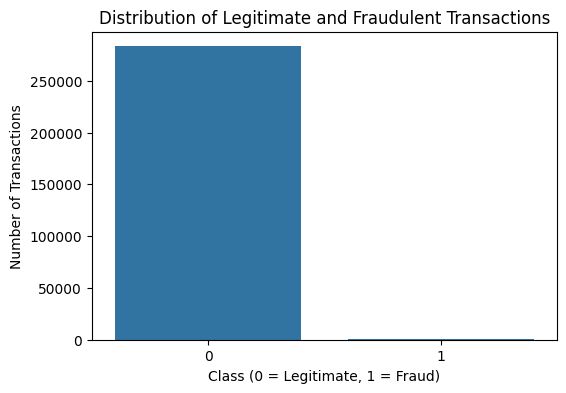

In [51]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df_clean, x="Class")

plt.title("Distribution of Legitimate and Fraudulent Transactions")

plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")

plt.ylabel("Number of Transactions")

plt.show()

In [52]:
print(df_clean["Amount"].describe())

count    283726.000000
mean         88.472687
std         250.399437
min           0.000000
25%           5.600000
50%          22.000000
75%          77.510000
max       25691.160000
Name: Amount, dtype: float64


In [53]:
amount_comparison = df_clean.groupby("Class")["Amount"].describe()

amount_comparison

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,283253.0,88.413575,250.379023,0.0,5.67,22.00,77.46,25691.16
1,473.0,123.871860,260.211041,0.0,1.00,9.82,105.89,2125.87


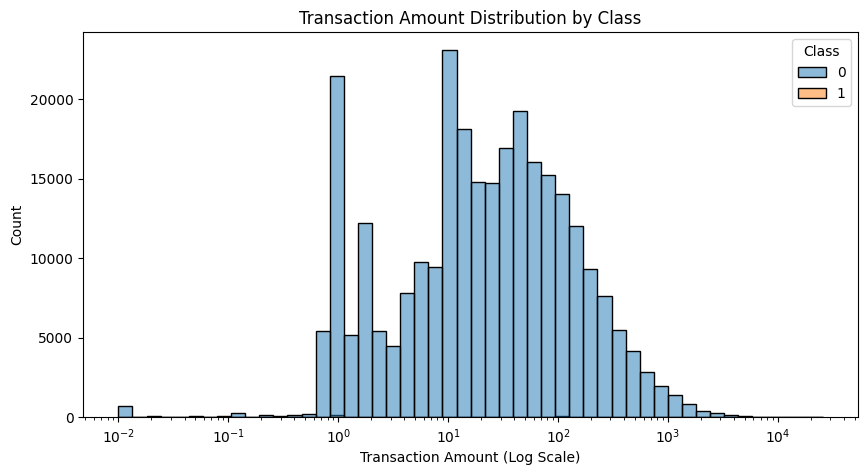

In [55]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df_clean,
    x="Amount",
    hue="Class",
    bins=50,
    log_scale=(True, False)
)

plt.title("Transaction Amount Distribution by Class")
plt.xlabel("Transaction Amount (Log Scale)")
plt.ylabel("Count")

plt.show()

In [62]:
X_train, X_test, y_train, y_test, scaler = prepare_data(df_clean)


----- DATA PREPARATION -----

Training Shape Before SMOTE: (226980, 30)
Training Shape After SMOTE: (453204, 30)

Training Class Distribution Before SMOTE:
Class
0    226602
1       378
Name: count, dtype: int64

Training Class Distribution After SMOTE:
Class
0    226602
1    226602
Name: count, dtype: int64

Test Shape: (56746, 30)


In [71]:
logistic_model = train_logistic_regression(
    X_train,
    y_train
)



Training Logistic Regression...



Logistic Regression RESULTS

Accuracy:  0.9737
Precision: 0.0530
Recall:    0.8737
F1 Score:  0.1000
ROC-AUC:   0.9619

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746



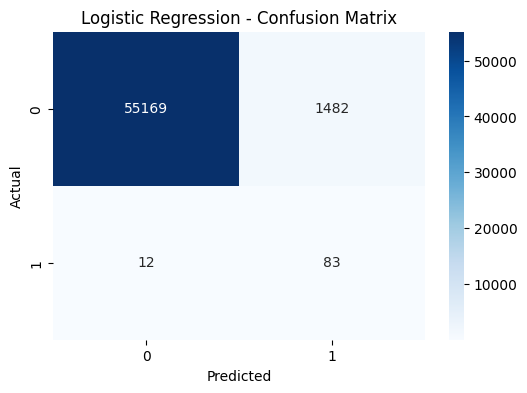

{'Model': 'Logistic Regression',
 'Accuracy': 0.9736721531033025,
 'Precision': np.float64(0.053035143769968054),
 'Recall': np.float64(0.8736842105263158),
 'F1 Score': np.float64(0.1),
 'ROC-AUC': np.float64(0.9618957810936585)}

In [72]:
logistic_results = evaluate_model(
    logistic_model,
    X_test,
    y_test,
    "Logistic Regression"
)
logistic_results

In [65]:
random_forest_model = train_random_forest(
    X_train,
    y_train
)


Training Random Forest...



Random Forest RESULTS

Accuracy:  0.9995
Precision: 0.9114
Recall:    0.7579
F1 Score:  0.8276
ROC-AUC:   0.9662

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.91      0.76      0.83        95

    accuracy                           1.00     56746
   macro avg       0.96      0.88      0.91     56746
weighted avg       1.00      1.00      1.00     56746



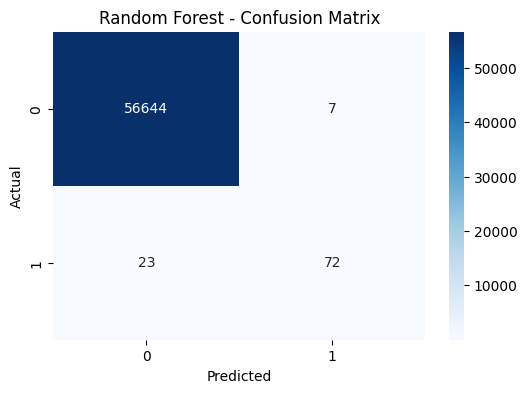

{'Model': 'Random Forest',
 'Accuracy': 0.9994713283755683,
 'Precision': np.float64(0.9113924050632911),
 'Recall': np.float64(0.7578947368421053),
 'F1 Score': np.float64(0.8275862068965517),
 'ROC-AUC': np.float64(0.9662031329404691)}

In [68]:
rf_results = evaluate_model(
    random_forest_model,
    X_test,
    y_test,
    "Random Forest"
)

rf_results

In [69]:
results_df = pd.DataFrame([
    logistic_results,
    rf_results
])

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.973672,0.053035,0.873684,0.100000,0.961896
1,Random Forest,0.999471,0.911392,0.757895,0.827586,0.966203


In [70]:
best_model = results_df.sort_values(
    by="F1 Score",
    ascending=False
)

best_model

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
1,Random Forest,0.999471,0.911392,0.757895,0.827586,0.966203
0,Logistic Regression,0.973672,0.053035,0.873684,0.100000,0.961896


In [73]:
results_df = pd.DataFrame([
    logistic_results,
    rf_results
])

results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
1,Random Forest,0.999471,0.911392,0.757895,0.827586,0.966203
0,Logistic Regression,0.973672,0.053035,0.873684,0.100000,0.961896


In [74]:
from sklearn.metrics import confusion_matrix

# Logistic Regression predictions
logistic_predictions = logistic_model.predict(X_test)

logistic_cm = confusion_matrix(
    y_test,
    logistic_predictions
)

print("Logistic Regression Confusion Matrix:")
print(logistic_cm)


# Random Forest predictions
rf_predictions = random_forest_model.predict(X_test)

rf_cm = confusion_matrix(
    y_test,
    rf_predictions
)

print("\nRandom Forest Confusion Matrix:")
print(rf_cm)

Logistic Regression Confusion Matrix:
[[55169  1482]
 [   12    83]]

Random Forest Confusion Matrix:
[[56644     7]
 [   23    72]]
